In [85]:
import joblib
import shap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
model = joblib.load("../models/rf_base.joblib")

data = pd.read_csv("../data/train_preprocessed.csv")
X = data.drop(columns=["fraud_label","user_id","transaction_id"])
y = data.fraud_label

## Feature importance

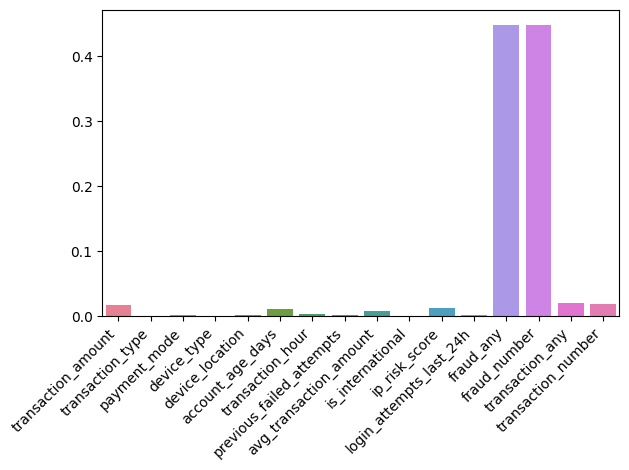

In [87]:
sns.barplot(
    y=model.feature_importances_,
    x=model.feature_names_in_,
    hue=model.feature_names_in_
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # Prevents labels from being cut off
plt.show()

## Shaps

In [74]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X)[:,:,1]

## Waterfall

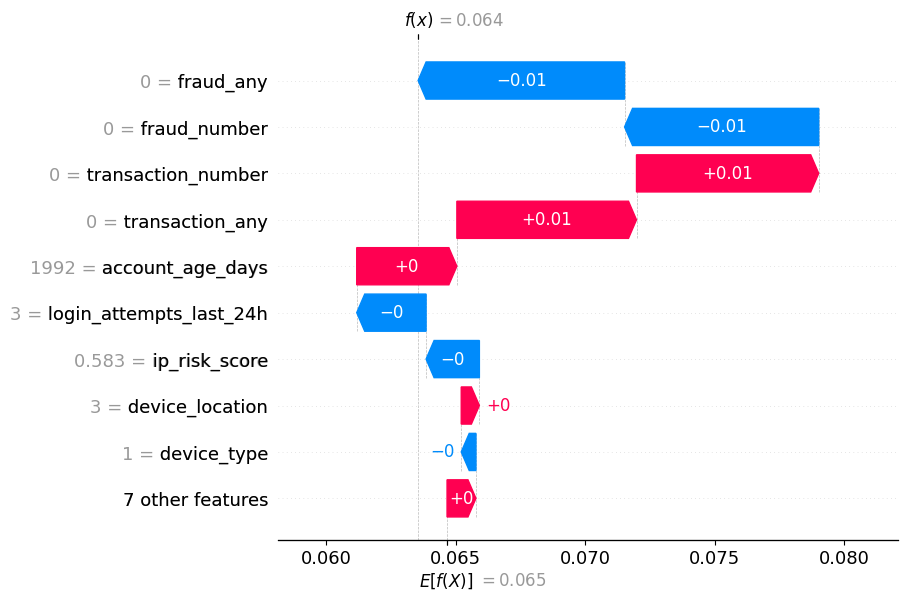

In [75]:
shap_values = explanation.values
shap.waterfall_plot(explanation[5])

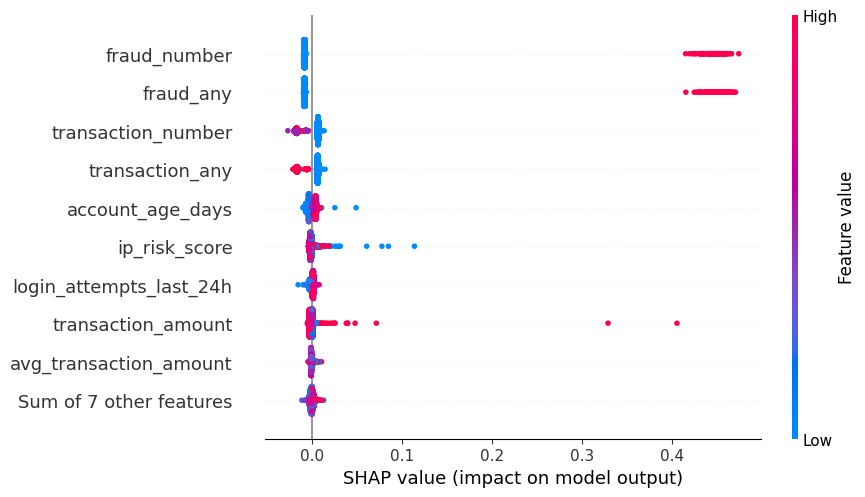

In [76]:
shap.plots.beeswarm(explanation)